In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from get_grad_cam import get_gradcam

In [5]:
resim_yolu = '/Users/sametkarayel/Desktop/C39P4thinF_original_IMG_20150622_110115_cell_110.png'
model_yolu = '/Users/sametkarayel/Desktop/sitma_tespiti/sitma_model/grad_model.keras'
model = tf.keras.models.load_model(model_yolu)

heatmap, tahmin = get_gradcam(model, resim_yolu, 'son_conv_katmani')


In [6]:
img = cv2.imread(resim_yolu)
img = cv2.resize(img, (128, 128))
heatmap_resized = cv2.resize(heatmap, (128, 128))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

In [7]:
# ısı haritasını renklendirip orijinal resimle birleştiriyoruz ve yaptık
heatmap_resized = cv2.resize(heatmap, (128, 128))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
sonuc = cv2.addWeighted(img, 0.5, heatmap_colored, 0.5, 0)

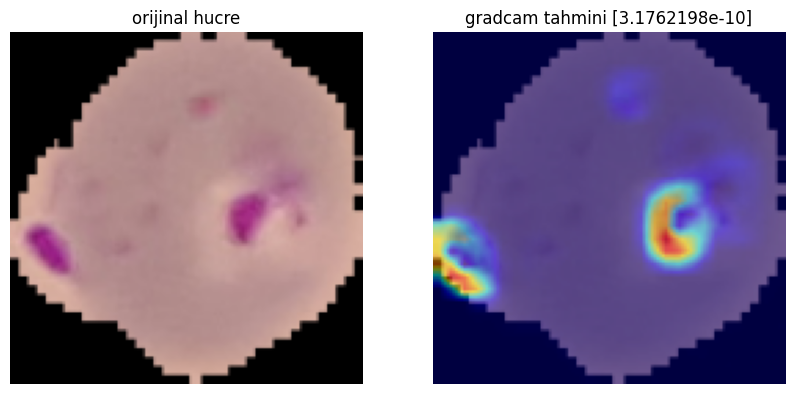

In [8]:
plt.figure(figsize=(10, 5))

# sol tarafa orijinal resmi basıyoruz ve yaptık
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # buradaki ismi img yaptık ve yaptık
plt.title("orijinal hucre")
plt.axis('off')

# sag tarafa gradcam sonucunu basıyoruz ve yaptık
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sonuc, cv2.COLOR_BGR2RGB))
plt.title(f"gradcam tahmini {tahmin}")
plt.axis('off')

plt.show()